# Importing Packages

In [85]:
import warnings
warnings.filterwarnings('ignore')

In [86]:
import numpy as np
import pandas as pd
import pickle # saving and loading trained model
from os import path

# importing required libraries for normalizing data
from sklearn import preprocessing
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder,LabelEncoder, MinMaxScaler, OneHotEncoder)
from sklearn.preprocessing import Normalizer, MaxAbsScaler , RobustScaler, PowerTransformer

# importing library for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Data Exploration

In [87]:
feature=["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
          "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells",
          "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
          "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count", 
          "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
          "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

In [88]:
train='data/nsl-kdd/KDDTrain+.txt'
test='data/nsl-kdd/KDDTest+.txt'
test21='data/nsl-kdd/KDDTest-21.txt'
train_data=pd.read_csv(train,names=feature)

In [89]:
train_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [90]:
# remove attribute 'difficulty_level'
train_data.drop(['difficulty'],axis=1,inplace=True)
train_data.shape

(125973, 42)

In [91]:
# number of attack labels 
train_data['label'].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [92]:
def change_label(df):
  df.label.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],'Dos',inplace=True)
  df.label.replace(['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'],'R2L',inplace=True)      
  df.label.replace(['ipsweep','mscan','nmap','portsweep','saint','satan'],'Probe',inplace=True)
  df.label.replace(['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'],'U2R',inplace=True)

In [93]:
change_label(train_data)

4    67343
0    45927
1    11656
2      995
3       52

In [94]:
# distribution of attack classes
train_data.label.value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [95]:
data = train_data.copy()

# Label Encoding

In [96]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
data['protocol_type']= label_encoder.fit_transform(data['protocol_type'])
data['service']= label_encoder.fit_transform(data['service'])
data['flag']= label_encoder.fit_transform(data['flag'])
data['label']= label_encoder.fit_transform(data['label'])

data['protocol_type'].unique()
data['service'].unique()
data['flag'].unique()
data['label'].unique()

array([11,  9, 21,  5, 15, 20, 10, 17, 18, 14,  0,  3,  2,  8, 16,  1,  4,
       22, 13,  6,  7, 19, 12])

In [97]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11


In [98]:
X = data.drop(["label"],axis =1)
y = data["label"]

# CCMI Feature

In [99]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif

In [100]:
selector = SelectPercentile(mutual_info_classif, percentile=30)
X_reduced = selector.fit_transform(X, y)
X_reduced.shape

(125973, 12)

In [101]:
cols = selector.get_support(indices=True)
selected_columns = X.iloc[:,cols].columns.tolist()
selected_columns

['service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'count',
 'serror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_serror_rate']

In [102]:
df = data[['service',
         'flag',
         'src_bytes',
         'dst_bytes',
         'count',
         'serror_rate',
         'same_srv_rate',
         'diff_srv_rate',
         'dst_host_srv_count',
         'dst_host_same_srv_rate',
         'dst_host_diff_srv_rate',
         'dst_host_serror_rate',
             'label']]
df.to_csv('nslkdd_processed.csv')

In [103]:
df['label'].value_counts()

label
11    67343
9     41214
17     3633
5      3599
15     2931
18     2646
10     1493
0       956
20      892
21      890
14      201
3        53
1        30
22       20
6        18
4        11
16       10
7         9
2         8
8         7
13        4
12        3
19        2
Name: count, dtype: int64

In [104]:
df.head()

,service,flag,src_bytes,dst_bytes,count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,label
0,20,9,491,0,2,0.0,1.00,0.00,25,0.17,0.03,0.00,11
1,44,9,146,0,13,0.0,0.08,0.15,1,0.00,0.60,0.00,11
2,49,5,0,0,123,1.0,0.05,0.07,26,0.10,0.05,1.00,9
3,24,9,232,8153,5,0.2,1.00,0.00,255,1.00,0.00,0.03,11
4,24,9,199,420,30,0.0,1.00,0.00,255,1.00,0.00,0.00,11


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.2)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((100778, 12), (100778,), (25195, 12), (25195,))

In [106]:
ML_Model = []
accuracy = []
f1score = []
recall = []
precision = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))    
    f1score.append(round(d, 3))

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# MLP - sgd

In [108]:
from sklearn.neural_network import MLPClassifier
# instantiate the model 
clf = MLPClassifier(solver='sgd')

# fit the model 
clf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_hat = clf.predict(X_test)

ann_acc = accuracy_score(y_hat, y_test)
ann_prec = precision_score(y_hat, y_test,average='weighted')
ann_rec = recall_score(y_hat, y_test,average='weighted')
ann_f1 = f1_score(y_hat, y_test,average='weighted')

In [109]:
storeResults('MLP - sgd',ann_acc,ann_prec,ann_rec,ann_f1)

# MLP - lbfgs

In [110]:
from sklearn.neural_network import MLPClassifier
# instantiate the model 
clf = MLPClassifier(solver='lbfgs')

# fit the model 
clf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_hat = clf.predict(X_test)

ann1_acc = accuracy_score(y_hat, y_test)
ann1_prec = precision_score(y_hat, y_test,average='weighted')
ann1_rec = recall_score(y_hat, y_test,average='weighted')
ann1_f1 = f1_score(y_hat, y_test,average='weighted')

In [111]:
storeResults('MLP - lbfgs',ann1_acc,ann1_prec,ann1_rec,ann1_f1)

# MLP - adam

In [112]:
from sklearn.neural_network import MLPClassifier
# instantiate the model 
clf = MLPClassifier(solver='adam')

# fit the model 
clf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_hat = clf.predict(X_test)

ann2_acc = accuracy_score(y_hat, y_test)
ann2_prec = precision_score(y_hat, y_test,average='weighted')
ann2_rec = recall_score(y_hat, y_test,average='weighted')
ann2_f1 = f1_score(y_hat, y_test,average='weighted')

In [113]:
storeResults('MLP - adam',ann2_acc,ann2_prec,ann2_rec,ann2_f1)

# Voting CLassifier

In [114]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

rfc = RandomForestClassifier()
parameters = {
    "n_estimators":[25],
    "max_depth":[20]
    
}

from sklearn.model_selection import GridSearchCV
forest = GridSearchCV(rfc,parameters,cv=10)

clf2 = DecisionTreeClassifier(random_state=100)

eclf1 = VotingClassifier(estimators=[('rf-parameter', forest), ('dt', clf2)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

In [115]:
storeResults('Voting Classifier',vot_acc,vot_prec,vot_rec,vot_f1)

# Stacking Classifier

In [116]:
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier

estimators = [('rf', forest),('dt', DecisionTreeClassifier(random_state=1))]

clf1 = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))


clf1.fit(X_train,y_train)

y_pred = clf1.predict(X_test)

stac_acc = accuracy_score(y_pred, y_test)
stac_prec = precision_score(y_pred, y_test,average='weighted')
stac_rec = recall_score(y_pred, y_test,average='weighted')
stac_f1 = f1_score(y_pred, y_test,average='weighted')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 34
[LightGBM] [Info] Start training from score -4.876886
[LightGBM] [Info] Start training from score -8.342622
[LightGBM] [Info] Start training from score -9.728916
[LightGBM] [Info] Start training from score -7.807103
[LightGBM] [Info] Start training from score -9.218090
[LightGBM] [Info] Start training from score -3.557215
[LightGBM] [Info] Start training from score -8.812625
[LightGBM] [Info] Start training from score -9.728916
[LightGBM] [Info] Start training from score -10.134381
[LightGBM] [Info] Start training from score -1.121456
[LightGBM] [Info] Start training from score -4.420648
[LightGBM] [Info] Start training from score -0.6246

In [117]:
storeResults('Stacking Classifier',stac_acc,stac_prec,stac_rec,stac_f1)

# Comparison

In [118]:
#creating dataframe
import pandas as pd
import numpy as np
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'f1_score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                        
                      })

In [119]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,MLP - sgd,0.928,0.949,0.928,0.973
1,MLP - lbfgs,0.009,0.018,0.009,0.603
2,MLP - adam,0.921,0.919,0.921,0.933
3,Voting Classifier,0.990,0.990,0.990,0.992
4,Stacking Classifier,0.905,0.903,0.905,0.958


# Modelling

In [120]:
import joblib
filename = 'model_vot.sav'
filename1 = 'model_stacking.sav'
joblib.dump(eclf1, filename)
joblib.dump(clf1, filename1)

['model_stacking.sav']

# Graph

In [121]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

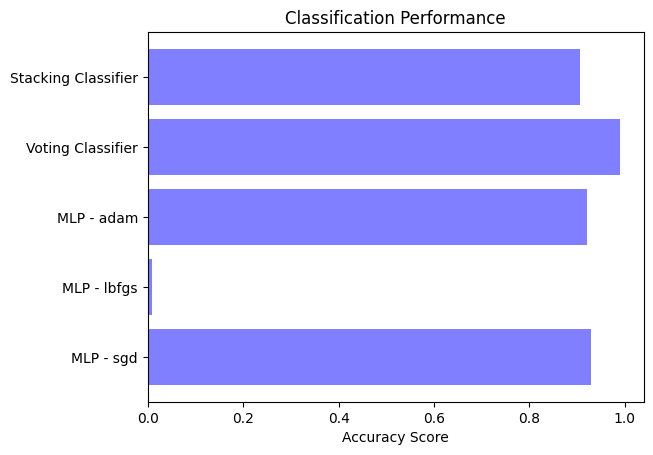

In [122]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

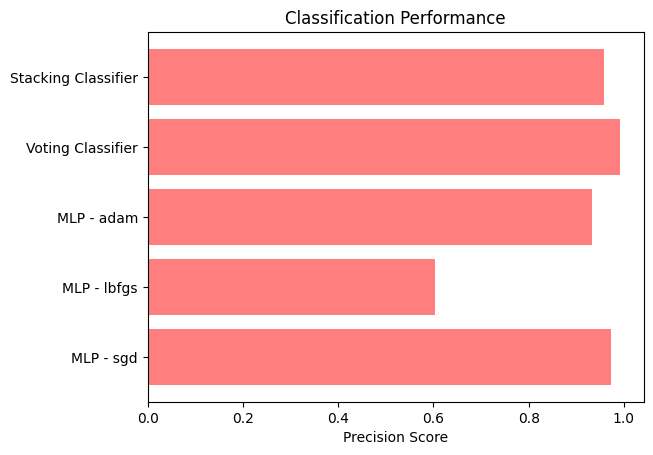

In [123]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

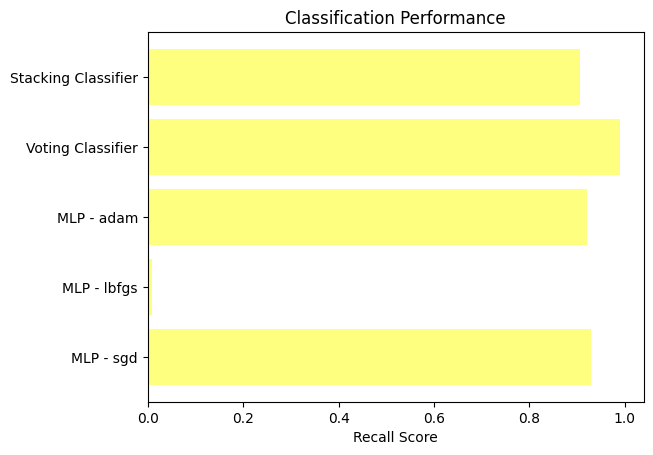

In [124]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

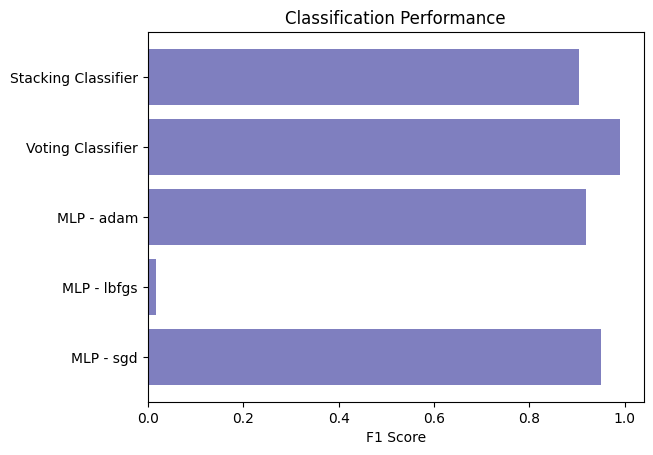

In [125]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()